In [8]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Load the preprocessed data from Phase 1
data = np.load('data/processed_data.npz', allow_pickle=True)
X_train, y_train = data['X_train'], data['y_train']
X_val, y_val = data['X_val'], data['y_val']
X_test, y_test = data['X_test'], data['y_test']
classes = data['classes']

num_classes = len(classes)
print("Number of classes:", num_classes)
print("Classes:", classes)
print("Train shape:", X_train.shape)

Number of classes: 9
Classes: [np.str_('Center') np.str_('Donut') np.str_('Edge-Loc')
 np.str_('Edge-Ring') np.str_('Loc') np.str_('Near-full')
 np.str_('Random') np.str_('Scratch') np.str_('none')]
Train shape: (29929, 64, 64, 1)


In [8]:
model = keras.Sequential([
    layers.Input(shape=(64, 64, 1)),

    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

NameError: name 'keras' is not defined

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks: stop early if val_loss stops improving, save best model
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint('model/best_model.h5', monitor='val_accuracy', save_best_only=True)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=callbacks
)

Epoch 1/30
935/936 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.4968 - loss: 1.4270

936/936 ━━━━━━━━━━━━━━━━━━━━ 76s 78ms/step - accuracy: 0.6466 - loss: 1.0106 - val_accuracy: 0.8528 - val_loss: 0.4561
Epoch 2/30
624/936 ━━━━━━━━━━━━━━━━━━━━ 22s 72ms/step - accuracy: 0.8021 - loss: 0.5723

KeyboardInterrupt: 

In [5]:
import os
os.makedirs('model', exist_ok=True)
print("Current working directory:", os.getcwd())

Current working directory: d:\capstone


In [7]:
# Evaluate on test set (data model has never seen)
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

NameError: name 'model' is not defined

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions on test set
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Detailed per-class report
print(classification_report(y_test, y_pred, target_names=classes))

201/201 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step
              precision    recall  f1-score   support

      Center       0.92      0.90      0.91       644
       Donut       0.87      0.93      0.90       375
    Edge-Loc       0.82      0.83      0.82       779
   Edge-Ring       0.97      0.98      0.98      1452
         Loc       0.72      0.57      0.64       539
   Near-full       0.95      0.99      0.97       375
      Random       0.93      0.89      0.91       375
     Scratch       0.66      0.17      0.27       375
        none       0.78      0.97      0.86      1500

    accuracy                           0.86      6414
   macro avg       0.85      0.80      0.81      6414
weighted avg       0.85      0.86      0.85      6414



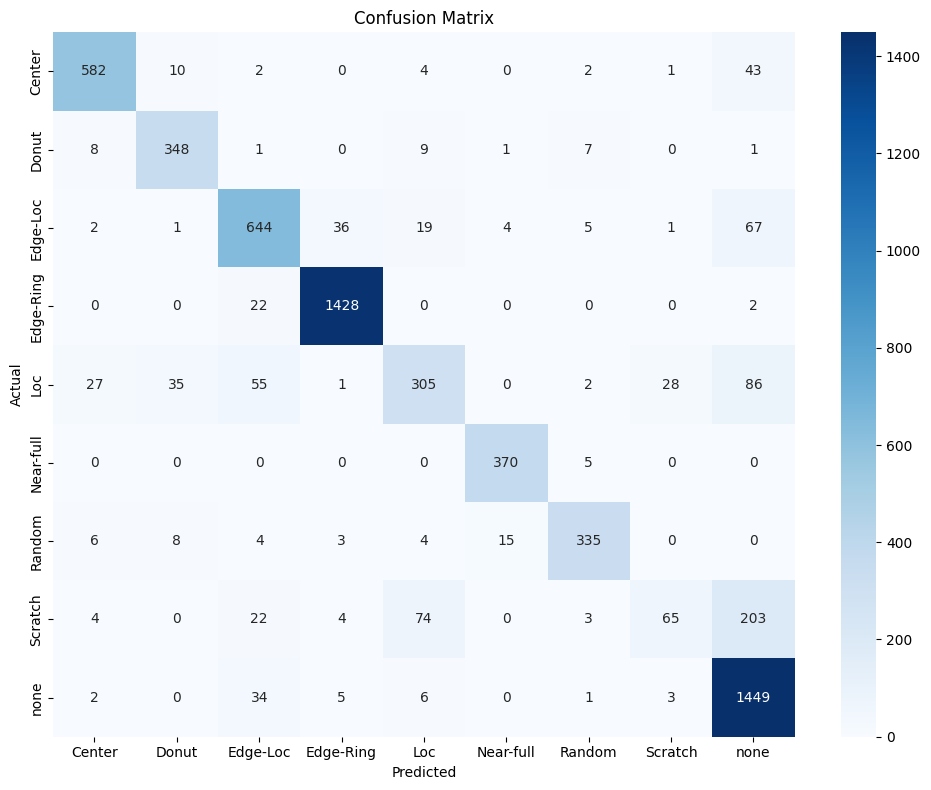

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [4]:
import pandas as pd
import numpy as np
import cv2
from sklearn.utils import resample

# Reload original data
df = pd.read_pickle('data/LSWMD.pkl')
df['label_len'] = df['failureType'].apply(lambda x: len(x))
labelled_df = df[df['label_len'] != 0].copy()

def extract_label(x):
    return x[0][0] if hasattr(x[0], '__len__') else x[0]

labelled_df['label'] = labelled_df['failureType'].apply(extract_label)

# Resize to 128x128 this time (was 64x64 before)
def resize_wafer(wafer_map, size=(128, 128)):
    wafer_map = np.array(wafer_map, dtype=np.uint8)
    return cv2.resize(wafer_map, size, interpolation=cv2.INTER_NEAREST)

print("Resizing all wafers to 128x128... (this will take a bit longer than before)")
labelled_df['resized'] = labelled_df['waferMap'].apply(lambda x: resize_wafer(x))

print("Done resizing.")

KeyboardInterrupt: 

In [2]:
def augment_wafer(wafer_map):
    """Randomly rotate or flip a wafer map to create a new sample"""
    choice = np.random.choice(['rot90', 'rot180', 'rot270', 'flip_h', 'flip_v'])
    if choice == 'rot90':
        return np.rot90(wafer_map, 1)
    elif choice == 'rot180':
        return np.rot90(wafer_map, 2)
    elif choice == 'rot270':
        return np.rot90(wafer_map, 3)
    elif choice == 'flip_h':
        return np.fliplr(wafer_map)
    else:
        return np.flipud(wafer_map)

def oversample_class(df, label, target_count):
    class_df = df[df['label'] == label]
    current_count = len(class_df)
    if current_count >= target_count:
        return class_df

    needed = target_count - current_count
    augmented_rows = []
    for i in range(needed):
        row = class_df.sample(1, random_state=i).iloc[0].copy()
        row['resized'] = augment_wafer(row['resized'])
        augmented_rows.append(row)

    augmented_df = pd.DataFrame(augmented_rows)
    return pd.concat([class_df, augmented_df])

# Undersample 'none'
none_df = labelled_df[labelled_df['label'] == 'none']
other_df = labelled_df[labelled_df['label'] != 'none']
none_sampled = resample(none_df, replace=False, n_samples=10000, random_state=42)
balanced_df = pd.concat([none_sampled, other_df])

# Oversample minority classes -- give Scratch EXTRA samples (3500 instead of 2500)
target_default = 2500
target_scratch = 3500   # extra boost for the weak class

minority_classes = ['Scratch', 'Random', 'Donut', 'Near-full']
final_parts = [balanced_df[~balanced_df['label'].isin(minority_classes)]]

for cls in minority_classes:
    target = target_scratch if cls == 'Scratch' else target_default
    final_parts.append(oversample_class(balanced_df, cls, target))

final_df = pd.concat(final_parts).reset_index(drop=True)

print("Final class distribution:")
print(final_df['label'].value_counts())

NameError: name 'labelled_df' is not defined

In [1]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# Convert to numpy arrays
X = np.stack(final_df['resized'].values)
X = X.reshape(-1, 128, 128, 1).astype('float32') / 3.0

le = LabelEncoder()
y = le.fit_transform(final_df['label'].values)

print("X shape:", X.shape)
print("Classes:", le.classes_)

# Train/val/test split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

# Compute class weights -- gives extra "importance" to weaker/minority classes during training
class_weights_arr = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(class_weights_arr))
print("\nClass weights:", class_weights)

# Save this new 128x128 dataset
np.savez('data/processed_data_128.npz',
         X_train=X_train, y_train=y_train,
         X_val=X_val, y_val=y_val,
         X_test=X_test, y_test=y_test,
         classes=le.classes_)
print("\nSaved to data/processed_data_128.npz")

NameError: name 'np' is not defined

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

model2 = keras.Sequential([
    layers.Input(shape=(128, 128, 1)),

    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(256, (3,3), activation='relu', padding='same'),   # extra block for bigger input
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(9, activation='softmax')
])

model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,503,497 (5.74 MB)

 Trainable params: 1,503,497 (5.74 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
try:
    print("X_train exists, shape:", X_train.shape)
except NameError:
    print("X_train NOT found — need to reload from saved file")

X_train NOT found — need to reload from saved file


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.utils.class_weight import compute_class_weight
import os

# Reload the preprocessed 128x128 data
data = np.load('data/processed_data_128.npz', allow_pickle=True)
X_train, y_train = data['X_train'], data['y_train']
X_val, y_val = data['X_val'], data['y_val']
X_test, y_test = data['X_test'], data['y_test']
classes = data['classes']

print("Reloaded successfully")
print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Classes:", classes)

# Recompute class weights
class_weights_arr = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(class_weights_arr))
print("Class weights:", class_weights)

Reloaded successfully
Train: (30629, 128, 128, 1) Val: (6563, 128, 128, 1) Test: (6564, 128, 128, 1)
Classes: [np.str_('Center') np.str_('Donut') np.str_('Edge-Loc')
 np.str_('Edge-Ring') np.str_('Loc') np.str_('Near-full')
 np.str_('Random') np.str_('Scratch') np.str_('none')]
Class weights: {0: np.float64(1.1321431211650772), 1: np.float64(1.9446984126984126), 2: np.float64(0.9370105237395986), 3: np.float64(0.5022464908828546), 4: np.float64(1.3531698696708636), 5: np.float64(1.9446984126984126), 6: np.float64(1.9446984126984126), 7: np.float64(1.3890702947845806), 8: np.float64(0.48617460317460315)}


In [ ]:
X_train = X_train.astype('float16')
X_val = X_val.astype('float16')
X_test = X_test.astype('float16')
import gc
gc.collect()
print("Converted to float16")

Converted to float16


In [ ]:
model2 = keras.Sequential([
    layers.Input(shape=(128, 128, 1)),

    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(9, activation='softmax')
])

model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,503,497 (5.74 MB)

 Trainable params: 1,503,497 (5.74 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import os

os.makedirs('model', exist_ok=True)

callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint('model/best_model_v2.keras', monitor='val_accuracy', save_best_only=True)
]

history2 = model2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    validation_batch_size=16,
    epochs=30,
    batch_size=16,
    class_weight=class_weights,
    callbacks=callbacks
)

NameError: name 'keras' is not defined

In [9]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.utils.class_weight import compute_class_weight
import os
import gc

# Reload data
data = np.load('data/processed_data_128.npz', allow_pickle=True)
X_train, y_train = data['X_train'], data['y_train']
X_val, y_val = data['X_val'], data['y_val']
X_test, y_test = data['X_test'], data['y_test']
classes = data['classes']

# Convert to float16 to save memory
X_train = X_train.astype('float16')
X_val = X_val.astype('float16')
X_test = X_test.astype('float16')
gc.collect()

# Class weights
class_weights_arr = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(class_weights_arr))

# Define model
model2 = keras.Sequential([
    layers.Input(shape=(128, 128, 1)),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),
    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),
    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(9, activation='softmax')
])

model2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Setup complete. Ready to train.")
print("Train shape:", X_train.shape)

Setup complete. Ready to train.
Train shape: (30629, 128, 128, 1)


In [12]:
os.makedirs('model', exist_ok=True)

callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint('model/best_model_v2.keras', monitor='val_accuracy', save_best_only=True)
]

history2 = model2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    validation_batch_size=16,
    epochs=30,
    batch_size=16,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/30
1915/1915 ━━━━━━━━━━━━━━━━━━━━ 299s 156ms/step - accuracy: 0.9007 - loss: 0.3076 - val_accuracy: 0.9295 - val_loss: 0.2155
Epoch 2/30
1915/1915 ━━━━━━━━━━━━━━━━━━━━ 321s 167ms/step - accuracy: 0.9065 - loss: 0.2813 - val_accuracy: 0.8947 - val_loss: 0.3143
Epoch 3/30
1915/1915 ━━━━━━━━━━━━━━━━━━━━ 337s 176ms/step - accuracy: 0.9044 - loss: 0.2947 - val_accuracy: 0.9291 - val_loss: 0.2185
Epoch 4/30
1915/1915 ━━━━━━━━━━━━━━━━━━━━ 350s 183ms/step - accuracy: 0.9074 - loss: 0.2821 - val_accuracy: 0.9256 - val_loss: 0.2199
Epoch 5/30
1915/1915 ━━━━━━━━━━━━━━━━━━━━ 329s 172ms/step - accuracy: 0.9076 - loss: 0.2765 - val_accuracy: 0.9252 - val_loss: 0.2143
Epoch 6/30
1915/1915 ━━━━━━━━━━━━━━━━━━━━ 365s 191ms/step - accuracy: 0.9105 - loss: 0.2731 - val_accuracy: 0.9194 - val_loss: 0.2499
Epoch 7/30
1915/1915 ━━━━━━━━━━━━━━━━━━━━ 1299s 678ms/step - accuracy: 0.9107 - loss: 0.2688 - val_accuracy: 0.9185 - val_loss: 0.2396
Epoch 8/30
1915/1915 ━━━━━━━━━━━━━━━━━━━━ 462s 241ms/step - a

In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_probs2 = model2.predict(X_test)
y_pred2 = np.argmax(y_pred_probs2, axis=1)

print(classification_report(y_test, y_pred2, target_names=classes))

206/206 ━━━━━━━━━━━━━━━━━━━━ 14s 68ms/step
              precision    recall  f1-score   support

      Center       0.95      0.95      0.95       644
       Donut       0.95      0.97      0.96       375
    Edge-Loc       0.91      0.86      0.88       779
   Edge-Ring       0.99      0.99      0.99      1452
         Loc       0.87      0.75      0.80       539
   Near-full       0.96      1.00      0.98       375
      Random       0.96      0.93      0.95       375
     Scratch       0.88      0.87      0.88       525
        none       0.89      0.96      0.93      1500

    accuracy                           0.93      6564
   macro avg       0.93      0.92      0.92      6564
weighted avg       0.93      0.93      0.93      6564



In [2]:
import pandas as pd
df = pd.read_pickle('data/LSWMD.pkl')
df['label_len'] = df['failureType'].apply(lambda x: len(x))
labelled_df = df[df['label_len'] != 0].copy()
labelled_df['label'] = labelled_df['failureType'].apply(lambda x: x[0][0] if hasattr(x[0], '__len__') else x[0])

In [3]:
import matplotlib.pyplot as plt

# Pick a real sample wafer map to use as test image
sample_row = labelled_df[labelled_df['label'] == 'Scratch'].iloc[0]
sample_wafer = sample_row['waferMap']

plt.imsave('test_scratch.png', sample_wafer, cmap='gray')
print("Saved test_scratch.png")

Saved test_scratch.png


In [4]:
for defect in ['Center', 'none', 'Edge-Ring', 'Donut']:
    sample = labelled_df[labelled_df['label'] == defect].iloc[0]
    plt.imsave(f'test_{defect}.png', sample['waferMap'], cmap='gray')
    print(f"Saved test_{defect}.png")
    

Saved test_Center.png
Saved test_none.png
Saved test_Edge-Ring.png
Saved test_Donut.png
